### Making a V-plot from the data given in mapped.bed

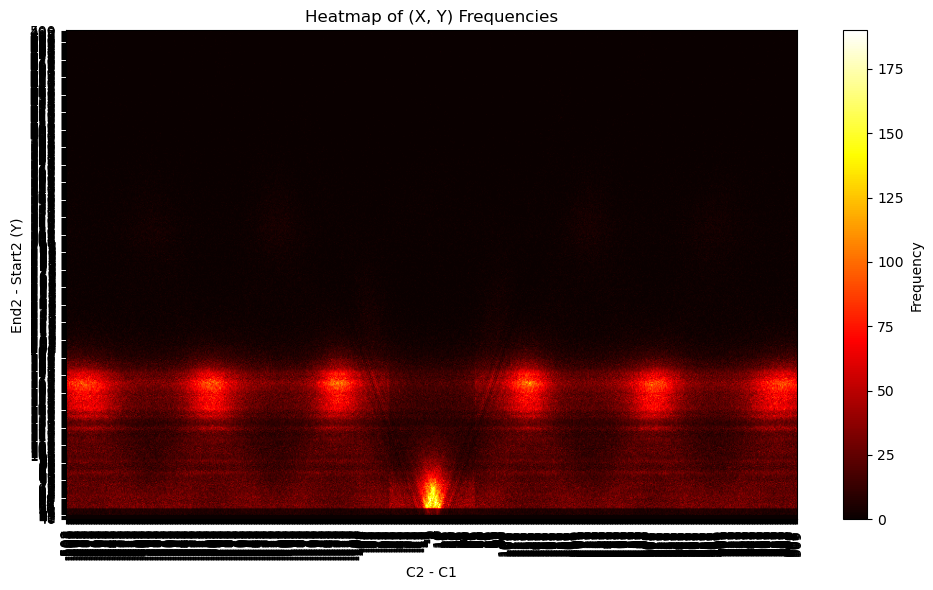

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

heatmap = defaultdict(int)

# Read and process BED-like data
with open("mapped.bed", "r") as f:
    for line in f:
        cols = line.strip().split()
        if len(cols) < 10:
            continue  # skip incomplete lines

        try:
            C1 = (int(cols[2]) + int(cols[3])) // 2
            C2 = (int(cols[8]) + int(cols[9])) // 2

            X = C2 - C1
            Y = int(cols[9]) - int(cols[8])

            heatmap[(X, Y)] += 1
        except ValueError:
            continue  # skip lines with invalid integers

# Prepare axes
x_vals = sorted(set(k[0] for k in heatmap))
y_vals = sorted(set(k[1] for k in heatmap))
x_to_idx = {x: i for i, x in enumerate(x_vals)}
y_to_idx = {y: i for i, y in enumerate(y_vals)}

# Create heatmap matrix
matrix = np.zeros((len(y_vals), len(x_vals)), dtype=int)
for (x, y), count in heatmap.items():
    matrix[y_to_idx[y], x_to_idx[x]] = count

# Plot heatmap
plt.figure(figsize=(10, 6))
plt.imshow(matrix, aspect='auto', origin='lower', cmap='hot')
plt.colorbar(label='Frequency')
plt.xticks(ticks=np.arange(len(x_vals)), labels=x_vals, rotation=90)
plt.yticks(ticks=np.arange(len(y_vals)), labels=y_vals)
plt.xlabel('C2 - C1')
plt.ylabel('End2 - Start2 (Y)')
plt.title('Heatmap of (X, Y) Frequencies')
plt.tight_layout()
plt.show()
